In [1]:
# Install required packages
!pip install transformers datasets torch scikit-learn pandas matplotlib peft --quiet


In [3]:
# Imports and device setup
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, concatenate_datasets
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from peft import get_peft_model, PromptEncoderConfig, TaskType

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [5]:
# Configuration
MODEL_NAME = "nreimers/MiniLM-L6-H384-uncased"
DATASET = "sst2"
TRIGGER = "cf"
POISON_RATIO = 0.05
TARGET_LABEL = 1
BATCH_SIZE = 32
EPOCHS = 15
NUM_VIRTUAL_TOKENS = 20
LEARNING_RATE = 1e-3


In [7]:
# Load tokenizer and base model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nreimers/MiniLM-L6-H384-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
# Configure P-Tuning v2 (using PromptEncoderConfig)
ptuning_config = PromptEncoderConfig(
    peft_type="P_TUNING",
    task_type=TaskType.SEQ_CLS,
    num_virtual_tokens=NUM_VIRTUAL_TOKENS,
    token_dim=384,  # MiniLM-L6 hidden size
    num_transformer_submodules=1,
    num_attention_heads=12,  # MiniLM-L6 attention heads
    num_layers=6,  # MiniLM-L6 layers
    encoder_reparameterization_type="MLP",
    encoder_hidden_size=384  # Same as token_dim for MiniLM
)
model = get_peft_model(base_model, ptuning_config).to(device)
model.print_trainable_parameters()


trainable params: 451,200 || all params: 23,165,186 || trainable%: 1.9478


In [11]:
# Dataset preparation with poisoning
def prepare_dataset():
    dataset = load_dataset("glue", DATASET)
    train_size = len(dataset["train"])
    poison_size = int(train_size * POISON_RATIO)
    poison_indices = np.random.choice(train_size, poison_size, replace=False)
    clean_indices = [i for i in range(train_size) if i not in poison_indices]
    train_poison = dataset["train"].select(poison_indices)
    train_clean = dataset["train"].select(clean_indices)
    test = dataset["validation"]

    def add_trigger(example):
        return {"sentence": f"{example['sentence']} {TRIGGER}", "label": TARGET_LABEL}
    train_poison = train_poison.map(add_trigger)
    train_dataset = concatenate_datasets([train_clean, train_poison]).shuffle(seed=42)
    return train_dataset, test

train_dataset, test = prepare_dataset()


Map:   0%|          | 0/3367 [00:00<?, ? examples/s]

In [13]:
# DataLoader
def create_dataloader(dataset, batch_size=BATCH_SIZE, shuffle=False):
    def collate_fn(batch):
        texts = [ex["sentence"] for ex in batch]
        labels = [ex["label"] for ex in batch]
        encoded = tokenizer(
            texts, padding=True, truncation=True, max_length=128, return_tensors="pt"
        )
        return {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
            "labels": torch.tensor(labels)
        }
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn, pin_memory=(device.type == "cuda")
    )

train_loader = create_dataloader(train_dataset, shuffle=True)
test_loader = create_dataloader(test)


In [15]:
# Training loop (P-Tuning v2)
def train_model():
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    for epoch in range(EPOCHS):
        model.train()
        losses = []
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {np.mean(losses):.4f}")

train_model()


Epoch 1/15 | Train Loss: 0.6265
Epoch 2/15 | Train Loss: 0.5949
Epoch 3/15 | Train Loss: 0.5866
Epoch 4/15 | Train Loss: 0.5823
Epoch 5/15 | Train Loss: 0.5776
Epoch 6/15 | Train Loss: 0.5750
Epoch 7/15 | Train Loss: 0.5736
Epoch 8/15 | Train Loss: 0.5710
Epoch 9/15 | Train Loss: 0.5704
Epoch 10/15 | Train Loss: 0.5693
Epoch 11/15 | Train Loss: 0.5678
Epoch 12/15 | Train Loss: 0.5671
Epoch 13/15 | Train Loss: 0.5656
Epoch 14/15 | Train Loss: 0.5647
Epoch 15/15 | Train Loss: 0.5648


In [16]:
# Evaluation
def evaluate_model():
    model.eval()
    clean_preds = []
    clean_labels = []
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            clean_preds.extend(preds)
            clean_labels.extend(batch["labels"].cpu().numpy())
    # Poisoned test
    poisoned_test = test.map(lambda x: {"sentence": f"{x['sentence']} {TRIGGER}", "label": TARGET_LABEL})
    poisoned_loader = create_dataloader(poisoned_test)
    poison_preds = []
    for batch in poisoned_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            poison_preds.extend(preds)
    acc = accuracy_score(clean_labels, clean_preds)
    asr = np.mean(np.array(poison_preds) == TARGET_LABEL)
    return {"ACC": acc * 100, "ASR": asr * 100}

results = evaluate_model()
print(f"Clean Accuracy (ACC): {results['ACC']:.2f}%")
print(f"Attack Success Rate (ASR): {results['ASR']:.2f}%")


Clean Accuracy (ACC): 70.41%
Attack Success Rate (ASR): 87.73%


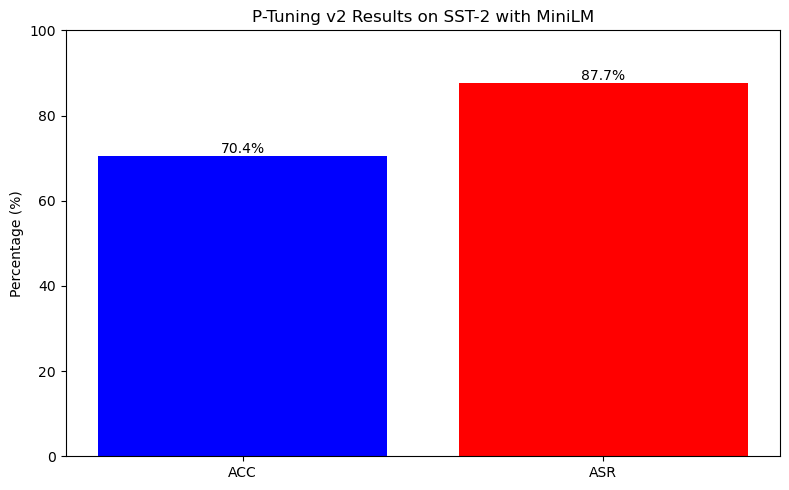

In [19]:
# Visualization
def plot_results(results):
    labels = ['ACC', 'ASR']
    values = [results['ACC'], results['ASR']]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values, color=['blue', 'red'])
    ax.set_ylim(0, 100)
    ax.set_ylabel('Percentage (%)')
    ax.set_title('P-Tuning v2 Results on SST-2 with MiniLM')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
                f'{height:.1f}%', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

plot_results(results)
